### Import Packages

In [61]:
import os
import tifffile
import numpy as np
import nibabel as nib

In [62]:
# Import basic packages for later use
import os
import shutil
from collections import OrderedDict

import json
import matplotlib.pyplot as plt
import nibabel as nib

import numpy as np
import torch

In [63]:
# check whether GPU accelerated computing is available
assert torch.cuda.is_available() # if there is an error here, enable GPU in the Runtime

In [64]:
torch.__version__

'2.2.1'

In [65]:
# check if nnunet can be imported
import nnunetv2

In [66]:
def make_if_dont_exist(folder_path,overwrite=False):
    """
    creates a folder if it does not exists
    input: 
    folder_path : relative path of the folder which needs to be created
    over_write :(default: False) if True overwrite the existing folder 
    """
    if os.path.exists(folder_path):
        
        if not overwrite:
            print(f"{folder_path} exists.")
        else:
            print(f"{folder_path} overwritten")
            shutil.rmtree(folder_path)
            os.makedirs(folder_path)

    else:
      os.makedirs(folder_path)
      print(f"{folder_path} created!")

In [67]:
root_dir = '/home/home/Documents'

In [68]:
mount_dir = root_dir
mount_dir = '/media/home/DATA10TB/MITOCHONDRIA/'

In [69]:
# Maybe move path of preprocessed data directly on content - this may be signifcantely faster!
print("Current Working Directory {}".format(os.getcwd()))
path_dict = {
    "nnUNet_raw" : '/media/home/DATA10TB/MITOCHONDRIA/nnUNet_raw', 
    "nnUNet_preprocessed" : os.path.join(mount_dir, "nnUNet_preprocessed"), # 1 experiment: 1 epoch took 112s
    "nnUNet_results" : os.path.join(mount_dir, "nnUNet_results"),
    "RAW_DATA_PATH" : os.path.join(mount_dir, "RawData"), # This is used here only for convenience (not necessary for nnU-Net)!
}
# Write paths to environment variables

for env_var, path in path_dict.items():
  os.environ[env_var] = path 

# Check whether all environment variables are set correct!
for env_var, path in path_dict.items():
  if os.getenv(env_var) != path:
    print("Error:")
    print("Environment Variable {} is not set correctly!".format(env_var))
    print("Should be {}".format(path))
    print("Variable is {}".format(os.getenv(env_var)))
  make_if_dont_exist(path, overwrite=False)

print("If No Error Occured Continue Forward. =)")

Current Working Directory /home/home/Documents
/media/home/DATA10TB/MITOCHONDRIA/nnUNet_raw exists.
/media/home/DATA10TB/MITOCHONDRIA/nnUNet_preprocessed exists.
/media/home/DATA10TB/MITOCHONDRIA/nnUNet_results exists.
/media/home/DATA10TB/MITOCHONDRIA/RawData exists.
If No Error Occured Continue Forward. =)


In [70]:
# Create Folderstructure for the new dataset!
dataset_name = 'Dataset1005_Mitochondria' #change here for different dataset name
nnunet_raw_data = os.path.join(os.getenv("nnUNet_raw"))
task_folder_name = os.path.join(nnunet_raw_data,dataset_name)
train_image_dir = os.path.join(task_folder_name,'imagesTr')
train_label_dir = os.path.join(task_folder_name,'labelsTr')
test_dir = os.path.join(task_folder_name,'imagesTs')

# Create Folder Structure for the SCGM dataset on the system
make_if_dont_exist(task_folder_name)
make_if_dont_exist(train_image_dir)
make_if_dont_exist(train_label_dir)
make_if_dont_exist(test_dir)

/media/home/DATA10TB/MITOCHONDRIA/nnUNet_raw/Dataset1005_Mitochondria exists.
/media/home/DATA10TB/MITOCHONDRIA/nnUNet_raw/Dataset1005_Mitochondria/imagesTr exists.
/media/home/DATA10TB/MITOCHONDRIA/nnUNet_raw/Dataset1005_Mitochondria/labelsTr exists.
/media/home/DATA10TB/MITOCHONDRIA/nnUNet_raw/Dataset1005_Mitochondria/imagesTs exists.


In [71]:
training_data_name="Dataset1005_Mitochondria"
test_data_name="Dataset1005_Mitochondria"

In [72]:
base_dir = '/home/home/Documents'

In [73]:
os.chdir(base_dir)

## 2D Data Prep

In [74]:
import os
import json
import numpy as np
import tifffile
import nibabel as nib

def get_valid_starts(image_size, patch_size, stride, min_shift_fraction=0.1):
    """
    Returns a list of valid start indices for a patch of 'patch_size'
    so that the patch does not exceed 'image_size'. Increments by 'stride'.
    If the final patch would go out of bounds, we consider adding a last start
    so that it ends exactly at 'image_size'. However, if that final shift is less
    than 'min_shift_fraction' of patch_size, we skip it.
    """

    print(f"[DEBUG] get_valid_starts() called with:")
    print(f"        image_size={image_size}, patch_size={patch_size}, stride={stride}, min_shift_fraction={min_shift_fraction}")

    starts = list(range(0, max(image_size - patch_size + 1, 1), stride))
    print(f"[DEBUG]  -> Initial range-based starts: {starts}")

    last_start = image_size - patch_size

    if last_start < 0:
        # If patch_size > image_size, skip or raise an exception
        print(f"[DEBUG]  -> patch_size ({patch_size}) exceeds image_size ({image_size}), returning empty list.")
        return []

    # Potentially add one final start so that the patch covers the boundary
    if starts and starts[-1] != last_start:
        shift_amount = last_start - starts[-1]
        print(f"[DEBUG]  -> Checking leftover shift: shift_amount={shift_amount}, last_start={last_start}")
        threshold = min_shift_fraction * patch_size
        if shift_amount >= threshold:
            starts.append(last_start)
            print(f"[DEBUG]  -> Added last_start={last_start} since shift_amount ({shift_amount}) >= threshold ({threshold})")

    print(f"[DEBUG]  -> Final starts: {starts}")
    return starts

def process_and_save_2d_slices(
    stack,
    chunks_dir,
    count,
    channel_name,
    test_mode=False,
    min_shift_fraction=0.1
):
    """
    Extracts 2D patches [1024 x 1024] from each z-slice, with 0.5 stride (512).
    If y or x is smaller than 1024, we pad equally on both sides of that dimension
    so that patch extraction can proceed without skipping.
    """
    import nibabel as nib

    # Extract original shape
    z, y, x = stack.shape
    patch_size = [1024, 1024]  # (y, x)
    stride = [512, 512]

    print(f"\n[DEBUG] process_and_save_2d_slices() called for channel='{channel_name}'")
    print(f"        Original stack.shape = (z={z}, y={y}, x={x})")

    # --------------------------------------------------------
    # 1) Pad y dimension if needed
    # --------------------------------------------------------
    if y < patch_size[0]:
        # how many total "missing" pixels to reach 1024
        pad_needed = patch_size[0] - y
        # pad equally on both sides
        pad_left = pad_needed // 2
        pad_right = pad_needed - pad_left
        print(f"[DEBUG] y < 1024, padding y equally: left={pad_left}, right={pad_right}")

        stack = np.pad(
            stack,
            pad_width=((0, 0), (pad_left, pad_right), (0, 0)),  # only pad y dimension
            mode='constant',
            constant_values=0
        )

    # --------------------------------------------------------
    # 2) Pad x dimension if needed
    # --------------------------------------------------------
    # (Note: we must recalc stack.shape, because y may have changed above)
    z, y, x = stack.shape
    if x < patch_size[1]:
        pad_needed = patch_size[1] - x
        pad_left = pad_needed // 2
        pad_right = pad_needed - pad_left
        print(f"[DEBUG] x < 1024, padding x equally: left={pad_left}, right={pad_right}")

        stack = np.pad(
            stack,
            pad_width=((0, 0), (0, 0), (pad_left, pad_right)),  # only pad x dimension
            mode='constant',
            constant_values=0
        )

    # Now the updated shape might be >= [1024, 1024]
    z, y, x = stack.shape
    print(f"[DEBUG] After optional padding, stack.shape = (z={z}, y={y}, x={x})")

    # --------------------------------------------------------
    # Use your existing get_valid_starts logic for the updated y, x
    # --------------------------------------------------------
    y_starts = get_valid_starts(y, patch_size[0], stride[0], min_shift_fraction)
    x_starts = get_valid_starts(x, patch_size[1], stride[1], min_shift_fraction)

    print(f"[DEBUG] Number of valid y starts: {len(y_starts)} -> {y_starts}")
    print(f"[DEBUG] Number of valid x starts: {len(x_starts)} -> {x_starts}")
    
    chunk_filenames = []  # will hold the paths of all created chunks

    # --------------------------------------------------------
    # 3) Extract patches from the padded stack
    # --------------------------------------------------------
    for z_idx in range(z):
        for start_y in y_starts:
            for start_x in x_starts:
                # Slice out the [1024 x 1024] patch
                chunk = stack[z_idx,
                              start_y:start_y + patch_size[0],
                              start_x:start_x + patch_size[1]]

                # Ensure the chunk is the correct size (should be now)
                if chunk.shape != tuple(patch_size):
                    print("[DEBUG]     Skipped due to shape mismatch.")
                    continue

                # ----------------------------------------------------
                # Optional: Binarize label or normalize raw to [0..255]
                # ----------------------------------------------------
                if channel_name == 'label':
                    chunk = np.where(chunk > 0, 1, 0).astype(np.uint8)
                else:
                    chunk_min, chunk_max = chunk.min(), chunk.max()
                    if chunk_max > chunk_min:
                        chunk = (chunk - chunk_min) / (chunk_max - chunk_min) * 255
                    else:
                        chunk = np.zeros_like(chunk)
                    chunk = chunk.astype(np.uint8)

                # Construct output filename
                count_str = f"{count:05d}"
                if channel_name == "raw":
                    chunk_name = os.path.join(chunks_dir, f"mitochondria_{count_str}_0000.nii.gz")
                else:
                    chunk_name = os.path.join(chunks_dir, f"mitochondria_{count_str}.nii.gz")

                # Save if not in test_mode
                if not test_mode:
                    chunk_nii = nib.Nifti1Image(chunk, affine=np.eye(4))
                    nib.save(chunk_nii, chunk_name)
                    chunk_filenames.append(chunk_name)
                else:
                    chunk_filenames.append(f"[TEST_MODE] {chunk_name}")

                count += 1

    print(f"[DEBUG] Total 2D patches created (for {channel_name}) after this call: {count}\n")
    return count, chunk_filenames


def main(directory, raw_chunks_dir, label_chunks_dir, test_mode=False):
    import shutil

    # List all files in directory
    files = [f for f in os.listdir(directory) if f.endswith('.tiff') or f.endswith('.tif')]
    files.sort()
    
    print("Files to be processed:")
    for f in files:
        print(f)
    
    proceed = input("\nDo you want to continue with the processing? (yes/no): ").strip().lower()
    if proceed != 'yes':
        print("Processing aborted by the user.")
        return
    
    # TEST MODE: only process first file
    if test_mode and len(files) > 1:
        print("\nTEST MODE: Only processing the first file and skipping saving.")
    
    # Check existing files to set the starting counts for RAW
    existing_raw = [f for f in os.listdir(raw_chunks_dir) if f.endswith('.nii.gz')]
    if existing_raw:
        existing_counts = []
        for f in existing_raw:
            # Expect format mitochondria_{count}_0000.nii.gz
            try:
                parts = f.split('_')
                count_str = parts[1]  # e.g. "00012"
                existing_counts.append(int(count_str))
            except:
                pass
        count_raw = max(existing_counts) + 1 if existing_counts else 0
    else:
        count_raw = 0

    # Check existing files to set the starting counts for LABEL
    existing_label = [f for f in os.listdir(label_chunks_dir) if f.endswith('.nii.gz')]
    if existing_label:
        existing_counts = []
        for f in existing_label:
            # Expect format mitochondria_{count}.nii.gz
            try:
                parts = f.split('_')
                count_str_with_ext = parts[1]  # e.g. "00012.nii.gz"
                count_str = count_str_with_ext.split('.')[0]  # "00012"
                existing_counts.append(int(count_str))
            except:
                pass
        count_labels = max(existing_counts) + 1 if existing_counts else 0
    else:
        count_labels = 0

    # Dictionary to map chunk basenames back to the source file
    chunk_source_mapping_2dmito = {}

    for file_path in files:
        print(f"\nPROCESSING: {file_path}")
        full_path = os.path.join(directory, file_path)

        try:
            stack = tifffile.imread(full_path)
            # If there's a dimension with size 2 or 3, move it to the end
            try:
                color_dim = np.where(np.array(stack.shape) == 2)[0][0]
                stack = np.moveaxis(stack, color_dim, -1)
                print('DIM 2 found, moving axis to end')
            except:
                color_dim = np.where(np.array(stack.shape) == 3)[0][0]
                stack = np.moveaxis(stack, color_dim, -1)
                print('DIM 3 found, moving axis to end')
            
            print(f"Loaded data from: {full_path}")
            print(f"Dimensions of input stack: {stack.shape}")
        except Exception as e:
            print(f"Error loading {full_path}. Error: {e}")
            continue

        # Green channel -> RAW
        raw_data = stack[..., 1]
        print(f"Dimensions of raw data (green channel): {raw_data.shape}")

        # Red channel -> LABEL
        labels = stack[..., 0]
        labels[labels > 1] = 1
        print(f"Dimensions of label data (red channel): {labels.shape}")

        # Debug print to confirm we only call process_and_save_2d_slices() once for RAW and once for LABEL
        print("\n[DEBUG] Calling process_and_save_2d_slices for RAW:")
        count_raw, raw_chunk_files = process_and_save_2d_slices(
            raw_data,
            chunks_dir=raw_chunks_dir,
            count=count_raw,
            channel_name="raw",
            test_mode=test_mode,
            min_shift_fraction=0.05
        )

        print("\n[DEBUG] Calling process_and_save_2d_slices for LABEL:")
        count_labels, label_chunk_files = process_and_save_2d_slices(
            labels,
            chunks_dir=label_chunks_dir,
            count=count_labels,
            channel_name="label",
            test_mode=test_mode,
            min_shift_fraction=0.05
        )

        # Map each chunk basename -> source file
        for chunk_file in raw_chunk_files:
            chunk_basename = os.path.basename(chunk_file)
            chunk_source_mapping_2dmito[chunk_basename] = file_path
        for chunk_file in label_chunk_files:
            chunk_basename = os.path.basename(chunk_file)
            chunk_source_mapping_2dmito[chunk_basename] = file_path

    # Write out the mapping to a JSON file
    mapping_filename = "chunk_source_mapping_2dmito.json"
    with open(mapping_filename, 'w') as f:
        json.dump(chunk_source_mapping_2dmito, f, indent=4)
    
    print(f"\nChunk-source mapping saved to {mapping_filename}")
    print("\nProcessing complete!")

import shutil

def ensure_clear_directory(dir_path):
    """
    Checks if `dir_path` exists and is not empty.
    If it's not empty, prompts the user to clear it.
    If the user confirms, all contents are removed.
    """
    if not os.path.exists(dir_path):
        # Directory does not exist, so create it
        os.makedirs(dir_path)
        print(f"Created directory: {dir_path}")
        return
    
    # Directory exists; check if it has contents
    files_in_dir = os.listdir(dir_path)
    if files_in_dir:
        print(f"The directory '{dir_path}' is not empty and contains {len(files_in_dir)} items.")
        proceed = input(f"Do you want to clear the directory '{dir_path}'? (yes/no): ").strip().lower()
        if proceed == 'yes':
            # Clear the directory
            for filename in files_in_dir:
                file_path = os.path.join(dir_path, filename)
                try:
                    if os.path.isfile(file_path) or os.path.islink(file_path):
                        os.unlink(file_path)
                    elif os.path.isdir(file_path):
                        shutil.rmtree(file_path)
                except Exception as e:
                    print(f'Failed to delete {file_path}. Reason: {e}')
            print(f"Directory '{dir_path}' has been cleared.")
        else:
            print(f"Directory '{dir_path}' will NOT be cleared.")
    else:
        print(f"The directory '{dir_path}' is empty (no need to clear).")

In [75]:
import pandas as pd

# show all rows and columns
pd.set_option('display.max_rows',    None)   # or e.g. 1000
pd.set_option('display.max_columns', None)   # or a specific number
# optional—allow very wide tables without wrapping:
pd.set_option('display.width',        None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

In [76]:
# %% [markdown]
# ## Scan for TIFF files, collect dimensions & compute summary statistics

# %%
from pathlib import Path
import pandas as pd
import tifffile

# directory to scan
base_dir = Path('/media/home/DATA10TB/MITOCHONDRIA/GT-4-16/TEST_TRAIN')

records = []

for tif_path in base_dir.rglob('*'):
    if tif_path.suffix.lower() in ('.tif', '.tiff'):
        try:
            with tifffile.TiffFile(str(tif_path)) as tif:
                depth = len(tif.pages)
                first = tif.pages[0].asarray()
                height, width = first.shape[:2]
                channels = first.shape[2] if first.ndim == 3 else 1
        except Exception as e:
            print(f"Could not read {tif_path.name}: {e}")
            continue

        records.append({
            'filename': tif_path.name,
            'width':      width,
            'height':     height,
            'depth':      depth,
            'channels':   channels,
        })

# build a DataFrame
df = pd.DataFrame(records)

# display the full table of filenames and their metrics
print(f"Found {len(df)} TIFF files:\n")
display(df)

# compute and display summary statistics for numeric columns
print("\nSummary statistics for dimensions and channels:")
stats = df[['width', 'height', 'depth', 'channels']].describe().astype(int)
display(stats)

Found 5 TIFF files:



,filename,width,height,depth,channels
0,b3GT051_A1_170428-a-1_OVERLAY-1-128.tif,3005,1139,128,3
1,b3GT055_160610b-a_OVERLAY-1-128.tif,2421,1214,128,3
2,b3GT055_area2_160616-a_OVERLAY-1-128.tif,2690,1213,128,3
3,b3GT073_160715-a_OVERLAY-327-454.tif,2339,1073,128,3
4,b3GT45_area1_170623-a_OVERLAY-129-257.tif,3005,1139,128,3



Summary statistics for dimensions and channels:


,width,height,depth,channels
count,5,5,5,5
mean,2692,1155,128,3
std,313,59,0,0
min,2339,1073,128,3
25%,2421,1139,128,3
50%,2690,1139,128,3
75%,3005,1213,128,3
max,3005,1214,128,3


In [77]:
directory = base_dir
raw_chunks_dir = train_image_dir
label_chunks_dir = train_label_dir

# Prompt for clearing the raw directory
ensure_clear_directory(raw_chunks_dir)

# Prompt for clearing the label directory
ensure_clear_directory(label_chunks_dir)

# Ensure output directories exist
for dir_path in [raw_chunks_dir, label_chunks_dir]:
    if not os.path.exists(dir_path):
        os.makedirs(dir_path)

# Run in TEST MODE for debugging
main(directory, raw_chunks_dir, label_chunks_dir, test_mode=False)

The directory '/media/home/DATA10TB/MITOCHONDRIA/nnUNet_raw/Dataset1005_Mitochondria/imagesTr' is not empty and contains 5376 items.


Do you want to clear the directory '/media/home/DATA10TB/MITOCHONDRIA/nnUNet_raw/Dataset1005_Mitochondria/imagesTr'? (yes/no):  yes


Directory '/media/home/DATA10TB/MITOCHONDRIA/nnUNet_raw/Dataset1005_Mitochondria/imagesTr' has been cleared.
The directory '/media/home/DATA10TB/MITOCHONDRIA/nnUNet_raw/Dataset1005_Mitochondria/labelsTr' is not empty and contains 5376 items.


Do you want to clear the directory '/media/home/DATA10TB/MITOCHONDRIA/nnUNet_raw/Dataset1005_Mitochondria/labelsTr'? (yes/no):  yes


Directory '/media/home/DATA10TB/MITOCHONDRIA/nnUNet_raw/Dataset1005_Mitochondria/labelsTr' has been cleared.
Files to be processed:
b3GT051_A1_170428-a-1_OVERLAY-1-128.tif
b3GT055_160610b-a_OVERLAY-1-128.tif
b3GT055_area2_160616-a_OVERLAY-1-128.tif
b3GT073_160715-a_OVERLAY-327-454.tif
b3GT45_area1_170623-a_OVERLAY-129-257.tif



Do you want to continue with the processing? (yes/no):  yes



PROCESSING: b3GT051_A1_170428-a-1_OVERLAY-1-128.tif
DIM 3 found, moving axis to end
Loaded data from: /media/home/DATA10TB/MITOCHONDRIA/GT-4-16/TEST_TRAIN/b3GT051_A1_170428-a-1_OVERLAY-1-128.tif
Dimensions of input stack: (128, 1139, 3005, 3)
Dimensions of raw data (green channel): (128, 1139, 3005)
Dimensions of label data (red channel): (128, 1139, 3005)

[DEBUG] Calling process_and_save_2d_slices for RAW:

[DEBUG] process_and_save_2d_slices() called for channel='raw'
        Original stack.shape = (z=128, y=1139, x=3005)
[DEBUG] After optional padding, stack.shape = (z=128, y=1139, x=3005)
[DEBUG] get_valid_starts() called with:
        image_size=1139, patch_size=1024, stride=512, min_shift_fraction=0.05
[DEBUG]  -> Initial range-based starts: [0]
[DEBUG]  -> Checking leftover shift: shift_amount=115, last_start=115
[DEBUG]  -> Added last_start=115 since shift_amount (115) >= threshold (51.2)
[DEBUG]  -> Final starts: [0, 115]
[DEBUG] get_valid_starts() called with:
        image_

## Verification of Data

Before going any further, verify that the data is present and labels and data matches.

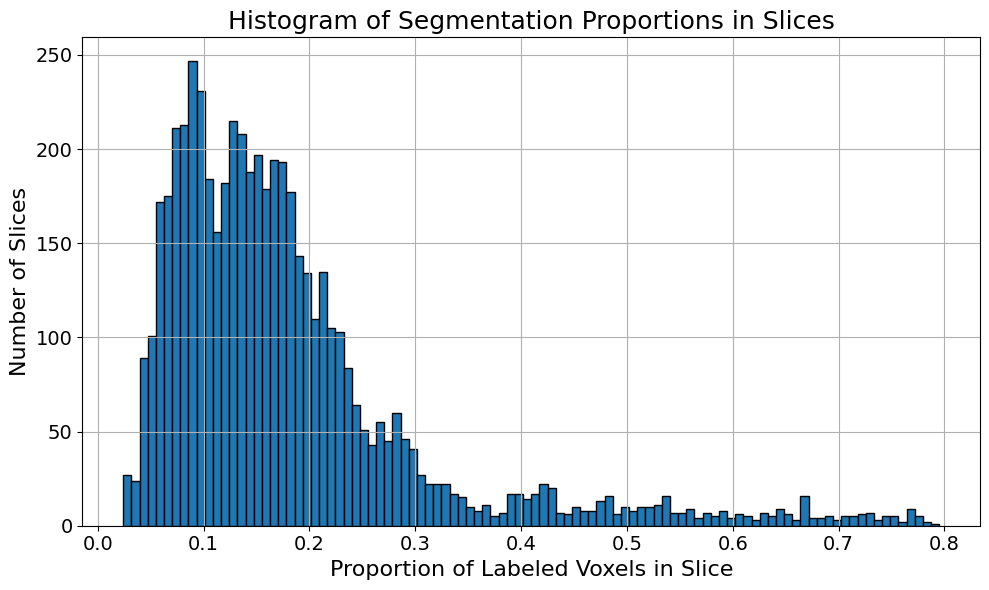

In [78]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

def plot_segmentation_histogram(slices_dir):
    # List all NIfTI files in the directory
    files = [f for f in os.listdir(slices_dir) if f.endswith('.nii.gz') or f.endswith('.nii')]
    files.sort()
    
    proportions = []

    for file_name in files:
        file_path = os.path.join(slices_dir, file_name)
        
        try:
            # Load the NIfTI file
            nii = nib.load(file_path)
            data = nii.get_fdata()
            
            # Ensure data is binary (0 or 1)
            data = np.where(data > 0, 1, 0)
            
            # Compute the proportion of labeled voxels in this chunk
            total_voxels = data.size
            labeled_voxels = np.count_nonzero(data)
            proportion = labeled_voxels / total_voxels
            proportions.append(proportion)
        except Exception as e:
            print(f"Error loading {file_path}. Error: {e}")
            continue

    # Plot histogram
    plt.figure(figsize=(10, 6))
    plt.hist(proportions, bins=100, edgecolor='black')
    plt.xlabel('Proportion of Labeled Voxels in Slice', fontsize=16)
    plt.ylabel('Number of Slices', fontsize=16)
    plt.title('Histogram of Segmentation Proportions in Slices', fontsize=18)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_segmentation_histogram(train_label_dir)

In [79]:
import os

# Define the folder path
folder_path = train_label_dir

print(folder_path)

# List all the .nii.gz files in the directory that start with 'mitochondria_' and end with '_0000.nii.gz'
nii_files = [f for f in os.listdir(folder_path) if f.startswith('mitochondria_') and f.endswith('_0000.nii.gz')]

# Loop through each .nii.gz file and rename
for nii_file in nii_files:
    # Construct the full path of the file
    full_path = os.path.join(folder_path, nii_file)
    
    # Remove the '_0000' from the file name and construct the new name
    new_file_name = nii_file.replace('_0000.nii.gz', '.nii.gz')
    new_full_path = os.path.join(folder_path, new_file_name)
    
    # Rename the file
    os.rename(full_path, new_full_path)

print("Renaming complete!")

/media/home/DATA10TB/MITOCHONDRIA/nnUNet_raw/Dataset1005_Mitochondria/labelsTr
Renaming complete!


In [80]:
print(train_image_dir)
print(train_label_dir)

/media/home/DATA10TB/MITOCHONDRIA/nnUNet_raw/Dataset1005_Mitochondria/imagesTr
/media/home/DATA10TB/MITOCHONDRIA/nnUNet_raw/Dataset1005_Mitochondria/labelsTr


In [81]:
train_files = os.listdir(train_image_dir)
label_files = os.listdir(train_label_dir)
print("train image files:",len(train_files))
print("train label files:",len(label_files))
print("Intersections:",len(set(train_files).intersection(set(label_files))))

train image files: 5376
train label files: 5376
Intersections: 0


In [82]:
#renaming to add the modality for SCGM there is only one modality 
#images should be added with 0000
#can be skipped if modality is already mentioned
#re-write for multiple modalities

def check_modality(filename):
    """
    check for the existence of modality
    return False if modality is not found else True
    """
    end = filename.find('.nii.gz')
    modality = filename[end-4:end]
    for mod in modality: 
        if not(ord(mod)>=48 and ord(mod)<=57): #if not in 0 to 9 digits
            return False
    return True

def rename_for_single_modality(directory):
    
    for file in os.listdir(directory):
        
        if check_modality(file)==False:
            new_name = file[:file.find('.nii.gz')]+"_0000.nii.gz"
            os.rename(os.path.join(directory,file),os.path.join(directory,new_name))
            print(f"Renamed to {new_name}")

rename_for_single_modality(train_image_dir)

In [83]:
task_folder_name

'/media/home/DATA10TB/MITOCHONDRIA/nnUNet_raw/Dataset1005_Mitochondria'

## Preprocessing

In [84]:
overwrite_json_file = True #make it True if you want to overwrite the dataset.json file in Dataset_folder
json_file_exist = False

if os.path.exists(os.path.join(task_folder_name,'dataset.json')):
    print('dataset.json already exist!')
    json_file_exist = True

if json_file_exist==False or overwrite_json_file:

    json_dict = OrderedDict()
    json_dict['name'] = dataset_name
    json_dict['description'] = "FIBSEM"
    json_dict['tensorImageSize'] = "2D"
    json_dict['reference'] = "N/A"
    json_dict['licence'] = "N/A"
    json_dict['release'] = "0.0"

    #you may mention more than one modality
    json_dict['channel_names'] = {
        "0": "SEM"
    }

    # set expected file ending
    json_dict["file_ending"] = ".nii.gz"

    #label names should be mentioned for all the labels in the dataset
    json_dict['labels'] = {
        "background": 0,
        "mitochondria": 1,
    }
    
    train_ids = os.listdir(train_label_dir)
    test_ids = os.listdir(test_dir)
    json_dict['numTraining'] = len(train_ids)
    json_dict['numTest'] = len(test_ids)
    
    with open(os.path.join(task_folder_name,"dataset.json"), 'w') as f:
        json.dump(json_dict, f, indent=4, sort_keys=True)

    if os.path.exists(os.path.join(task_folder_name,'dataset.json')):
        if json_file_exist==False:
            print('dataset.json created!')
        else: 
            print('dataset.json overwritten!')

dataset.json already exist!
dataset.json overwritten!


In [85]:
main_dir = '/home/home/Documents/'
main_dir = '/media/home/DATA10TB/MITOCHONDRIA/'

In [86]:
os.environ['nnUNet_raw_data_base'] = os.path.join(main_dir,'nnUNet_raw')
os.environ['nnUNet_preprocessed'] = os.path.join(main_dir,'nnUNet_preprocessed')
os.environ['RESULTS_FOLDER'] = os.path.join(main_dir,'nnUNet_results')

In [87]:
!nnUNetv2_plan_and_preprocess -d 1005 -c 2d --verify_dataset_integrity

Fingerprint extraction...
Dataset1005_Mitochondria
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Experiment planning...
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 3, 'patch_size': (1024, 1024), 'median_image_size_in_voxels': array([1024.,  987.]), 'spacing': array([1., 1.]), 'normalization_schemes': ['ZScoreNormalization'], 'use_mask_for_norm': [False], 'resampling_fn_data': 'resample_data_or_seg_to_shape', 'resampling_fn_seg': 'resample_data_or_seg_to_shape', 'resampling_fn_data_kwargs': {'is_seg': False, 'order': 3, 'order_z': 0, 'force_separate_z': None}, 'resampling_fn_seg_kwargs': {'is_seg': True, 'order': 1, 'order_z': 0, 'force_separate_z': None}, 'resampling_fn_probabilities': 'resample_data_or_seg_to_shape', 'resam

In [88]:
import json

# Assuming 'nnUNetPlans.json' is in the same directory as your script
file_name = os.path.join(os.environ['nnUNet_preprocessed'], dataset_name, 'nnUNetPlans.json')

# Load the JSON data from the file
with open(file_name, 'r') as file:
    data = json.load(file)

# Modify the 'patch_size' under 'configurations' -> '2d'
data['configurations']['2d']['patch_size'] = [1024, 1024]
data['configurations']['2d']['batch_size'] = 4

# Save the modified data back to the file
with open(file_name, 'w') as file:
    json.dump(data, file, indent=4)

In [89]:
import json
import os
import random
from collections import Counter

# ——— CONFIG ———
json_path    = 'chunk_source_mapping_2dmito.json'

# ——— Step 1: Read the JSON file ———
if not os.path.exists(json_path):
    raise FileNotFoundError(f"JSON file not found: {json_path}")
with open(json_path, 'r') as f:
    data = json.load(f)

# ——— Step 2: Count unique volume names ———
values        = list(data.values())
unique_values = set(values)
print(f'Number of unique values (volumes): {len(unique_values)}\n')

# ——— Step 3: Display each value and its counts ———
value_counts = Counter(values)
for vol, cnt in value_counts.items():
    print(f'{vol}: {cnt}')
print()

# ——— Step 4: Map volume_name → list of chunk keys ———
value_to_keys = {}
for chunk_key, vol in data.items():
    value_to_keys.setdefault(vol, []).append(chunk_key)

# ——— Step 5: Shuffle volumes and split into folds ———
all_values = list(unique_values)
random.shuffle(all_values)

num_folds = 5
n         = len(all_values)
fold_size = n // num_folds
rem       = n % num_folds

folds = []
start = 0
for i in range(num_folds):
    size = fold_size + (1 if i < rem else 0)
    folds.append(all_values[start:start+size])
    start += size

# ——— Step 6: Create splits and top-level summary ———
splits   = []
toplevel = []

def clean_key(k):
    k = k.replace('.nii.gz', '')
    if k.endswith('_0000'):
        k = k[:-5]
    return k

for i in range(num_folds):
    val_vols   = folds[i]
    train_vols = [v for j, f in enumerate(folds) if j != i for v in f]

    # gather raw chunk keys
    val_raw   = [k for v in val_vols   for k in value_to_keys[v]]
    train_raw = [k for v in train_vols for k in value_to_keys[v]]

    # clean & dedupe
    val_keys   = sorted({clean_key(k) for k in val_raw})
    train_keys = sorted({clean_key(k) for k in train_raw})

    # print fold info
    print(f"Fold {i+1}:")
    print(f"  Validation Volumes ({len(val_vols)}): {val_vols}")
    print(f"  Total validation keys: {len(val_keys)}\n")
    print(f"  Training Volumes ({len(train_vols)}): {train_vols}")
    print(f"  Total training keys: {len(train_keys)}\n")

    # accumulate JSON entries
    toplevel.append({
        "fold": i+1,
        "validation_volumes":    val_vols,
        "total_validation_keys": len(val_keys),
        "training_volumes":      train_vols,
        "total_training_keys":   len(train_keys)
    })
    splits.append({
        "train": train_keys,
        "val":   val_keys
    })

# ——— Step 7: Write both JSON files ———
base_dir      = os.path.join(os.environ['nnUNet_raw_data_base'], dataset_name)
os.makedirs(base_dir, exist_ok=True)

manual_path   = os.path.join(base_dir, 'splits_manual.json')
toplevel_path = os.path.join(base_dir, 'splits_toplevel.json')

with open(manual_path, 'w') as f:
    json.dump(splits, f, indent=4)

with open(toplevel_path, 'w') as f:
    json.dump(toplevel, f, indent=4)

print(f"Splits have been saved to:\n • {manual_path}\n • {toplevel_path}")

Number of unique values (volumes): 5

b3GT051_A1_170428-a-1_OVERLAY-1-128.tif: 2560
b3GT055_160610b-a_OVERLAY-1-128.tif: 2048
b3GT055_area2_160616-a_OVERLAY-1-128.tif: 2560
b3GT073_160715-a_OVERLAY-327-454.tif: 1024
b3GT45_area1_170623-a_OVERLAY-129-257.tif: 2560

Fold 1:
  Validation Volumes (1): ['b3GT055_area2_160616-a_OVERLAY-1-128.tif']
  Total validation keys: 1280

  Training Volumes (4): ['b3GT073_160715-a_OVERLAY-327-454.tif', 'b3GT45_area1_170623-a_OVERLAY-129-257.tif', 'b3GT055_160610b-a_OVERLAY-1-128.tif', 'b3GT051_A1_170428-a-1_OVERLAY-1-128.tif']
  Total training keys: 4096

Fold 2:
  Validation Volumes (1): ['b3GT073_160715-a_OVERLAY-327-454.tif']
  Total validation keys: 512

  Training Volumes (4): ['b3GT055_area2_160616-a_OVERLAY-1-128.tif', 'b3GT45_area1_170623-a_OVERLAY-129-257.tif', 'b3GT055_160610b-a_OVERLAY-1-128.tif', 'b3GT051_A1_170428-a-1_OVERLAY-1-128.tif']
  Total training keys: 4864

Fold 3:
  Validation Volumes (1): ['b3GT45_area1_170623-a_OVERLAY-129-257.

## Training nnU-Net

Generic Training Commands:

```nnUNetv2_train Dataset_NAME_OR_ID CONFIGURATION FOLD -tr TRAINER_CLASS_NAME (additional options)```

For 2D:  ```nnUNetv2_train DATASET_NAME_OR_ID 2d FOLD```

For 3D Full resolution: ```nnUNetv2_train DATASET_NAME_OR_ID 3d_fullres FOLD```

For Cascaded 3D:

First Run lowres: ```nnUNetv2_train DATASET_NAME_OR_ID 3d_lowres FOLD```

Then Run fullres: ```nnUNetv2_train DATASET_NAME_OR_ID 3d_cascade_fullres FOLD```

In [59]:
!nnUNetv2_train --help

usage: nnUNetv2_train [-h] [-tr TR] [-p P]
                      [-pretrained_weights PRETRAINED_WEIGHTS]
                      [-num_gpus NUM_GPUS] [--use_compressed] [--npz] [--c]
                      [--val] [--val_best] [--disable_checkpointing]
                      [-device DEVICE]
                      dataset_name_or_id configuration fold

positional arguments:
  dataset_name_or_id    Dataset name or ID to train with
  configuration         Configuration that should be trained
  fold                  Fold of the 5-fold cross-validation. Should be an int
                        between 0 and 4.

options:
  -h, --help            show this help message and exit
  -tr TR                [OPTIONAL] Use this flag to specify a custom trainer.
                        Default: nnUNetTrainer
  -p P                  [OPTIONAL] Use this flag to specify a custom plans
                        identifier. Default: nnUNetPlans
  -pretrained_weights PRETRAINED_WEIGHTS
                        [O

In [90]:
!nnUNetv2_train 1005 2d 0 -tr nnUNetTrainer_100epochs --c

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

/home/home/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "

This is the configuration used by this training:
Configuration name: 2d
 {'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 4, 'patch_size': [1024, 1024], 'median_image_size_in_voxels': [1024.0, 987.0], 'spacing': [1.0, 1.0], 'normalization_schemes': ['ZScoreNor

In [33]:
!nnUNetv2_train 1005 2d 1 -tr nnUNetTrainer_100epochs --c

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

/home/home/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "

This is the configuration used by this training:
Configuration name: 2d
 {'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 16, 'patch_size': [1024, 1024], 'median_image_size_in_voxels': [512.0, 64.0], 'spacing': [1.0, 1.0], 'normalization_schemes': ['ZScoreNorm

In [34]:
!nnUNetv2_train 1005 2d 2 -tr nnUNetTrainer_100epochs --c

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

/home/home/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "

This is the configuration used by this training:
Configuration name: 2d
 {'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 16, 'patch_size': [1024, 1024], 'median_image_size_in_voxels': [512.0, 64.0], 'spacing': [1.0, 1.0], 'normalization_schemes': ['ZScoreNorm

In [35]:
!nnUNetv2_train 1005 2d 3 -tr nnUNetTrainer_100epochs --c

^C
Traceback (most recent call last):
  File "/home/home/miniconda3/bin/nnUNetv2_train", line 5, in <module>
    from nnunetv2.run.run_training import run_training_entry
  File "/home/home/miniconda3/lib/python3.12/site-packages/nnunetv2/run/run_training.py", line 12, in <module>
    from nnunetv2.training.nnUNetTrainer.nnUNetTrainer import nnUNetTrainer
  File "/home/home/miniconda3/lib/python3.12/site-packages/nnunetv2/training/nnUNetTrainer/nnUNetTrainer.py", line 30, in <module>
    from nnunetv2.inference.predict_from_raw_data import nnUNetPredictor
  File "/home/home/miniconda3/lib/python3.12/site-packages/nnunetv2/inference/predict_from_raw_data.py", line 22, in <module>
    from nnunetv2.inference.data_iterators import PreprocessAdapterFromNpy, preprocessing_iterator_fromfiles, \
  File "/home/home/miniconda3/lib/python3.12/site-packages/nnunetv2/inference/data_iterators.py", line 12, in <module>
    from nnunetv2.preprocessing.preprocessors.default_preprocessor import DefaultP

In [36]:
!nnUNetv2_train 1005 2d 4 -tr nnUNetTrainer_100epochs --c

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

^C
Traceback (most recent call last):
  File "/home/home/miniconda3/bin/nnUNetv2_train", line 8, in <module>
    sys.exit(run_training_entry())
             ^^^^^^^^^^^^^^^^^^^^
  File "/home/home/miniconda3/lib/python3.12/site-packages/nnunetv2/run/run_training.py", line 268, in run_training_entry
    run_training(args.dataset_name_or_id, args.configuration, args.fold, args.tr, args.p, args.pretrained_weights,
  File "/home/home/miniconda3/lib/python3.12/site-packages/nnunetv2/run/run_training.py", line 204, in run_training
    nnunet_trainer.run_training()
  File "/ho

In [ ]:
!nnUNetv2_train 205 3d_fullres 0 -tr nnUNetTrainer_100epochs -pretrained_weights '/media/home/DATA10TB/MITOCHONDRIA/nnUNet_results/Dataset205_Mitochondria/pretrained_weights/checkpoint_final.pth'

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

/home/home/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "
################### Loading pretrained weights from file  /media/home/DATA10TB/MITOCHONDRIA/nnUNet_results/Dataset205_Mitochondria/pretrained_weights/checkpoint_final.pth ###################
Below is the list of overlapping blocks in pretrained model and nnUNet architecture:
encoder.stages.0.0.convs.0.conv.